
# Project: Investigate a Dataset (Movies)

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### First, I have to see the relation between variables through a heatmap.

#### The Questions
1. **What are the top 10 directors by revenue?**  
2. **What are the best 5 films according to rating and revenue?**  
3. **What are the top 5 genres in the data?**  
4. **Is there a relationship between year and number of films?**  


<a id='wrangling'></a>
## Data Wrangling


### General Properties

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv("tmdb-movies.csv")


In [2]:
data.head() # to show the first 5 rows of data 

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,Every generation has a story.,...,Thirty years after defeating the Galactic Empi...,136,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,Vengeance Hits Home,...,Deckard Shaw seeks revenge against Dominic Tor...,137,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09


In [3]:
print(data.info()) # here to see the data type of each column
data.describe() #to see the stats it will help in detecting outliers

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.000000,10866.000000,1.086600e+04,1.086600e+04,10866.000000,10866.000000,10866.000000,10866.000000,1.086600e+04,1.086600e+04
mean,66064.177434,0.646441,1.462570e+07,3.982332e+07,102.070863,217.389748,5.974922,2001.322658,1.755104e+07,5.136436e+07
std,92130.136561,1.000185,3.091321e+07,1.170035e+08,31.381405,575.619058,0.935142,12.812941,3.430616e+07,1.446325e+08
min,5.000000,0.000065,0.000000e+00,0.000000e+00,0.000000,10.000000,1.500000,1960.000000,0.000000e+00,0.000000e+00
25%,10596.250000,0.207583,0.000000e+00,0.000000e+00,90.000000,17.000000,5.400000,1995.000000,0.000000e+00,0.000000e+00
50%,20669.000000,0.383856,0.000000e+00,0.000000e+00,99.000000,38.000000,6.000000,2006.000000,0.000000e+00,0.000000e+00
75%,75610.000000,0.713817,1.500000e+07,2.400000e+07,111.000000,145.750000,6.600000,2011.000000,2.085325e+07,3.369710e+07
max,417859.000000,32.985763,4.250000e+08,2.781506e+09,900.000000,9767.000000,9.200000,2015.000000,4.250000e+08,2.827124e+09



### Data Cleaning removing unused columns and duplicated values

In [4]:
# After discussing the structure of the data and any problems that need to be
#   cleaned, perform those cleaning steps in the second part of this section.
data = data.drop(["id" , "imdb_id" , "tagline" , "keywords" , "homepage" , "runtime" , "production_companies"] , axis=1) #here 
print(data.isna().sum()) # -> to check number of null values 
print(data.duplicated().sum()) #-> 1 duplicated
data = data.drop_duplicates() # here i removed the duplicates


popularity         0
budget             0
revenue            0
original_title     0
cast              76
director          44
overview           4
genres            23
release_date       0
vote_count         0
vote_average       0
release_year       0
budget_adj         0
revenue_adj        0
dtype: int64
1


<a id='eda'></a>
## Exploratory Data Analysis


### here i made a function to help me to do the graph stuff

In [5]:
def show(ax=None, title_label=False, x_label=False, y_label=False, fig_size=(20, 10)):
    """
        this function is used to make the graphs by passing the args below.

        Args:
            ax (sns object): the plot with the data.
            title_label (string): Description of the second parameter.
            x_label (string) : that is for the label of the x axis .
            y_label (string) : that is for the label of the y axis .
            fig_siz (tuple) : that for the size of the plot 
        Returns:
            None (nothing)
    """
    
    if ax is None: 
        ax = plt.gca()

    fig = ax.get_figure()  
    fig.set_size_inches(*fig_size)  

    if title_label:
        ax.set_title(title_label)
    if x_label:
        ax.set_xlabel(x_label)
    if y_label:
        ax.set_ylabel(y_label)
    
    plt.show()


## here i want to see the relationship between variables to make an effective graph.
### here i found that the most of high budget movies tend to have more revenue

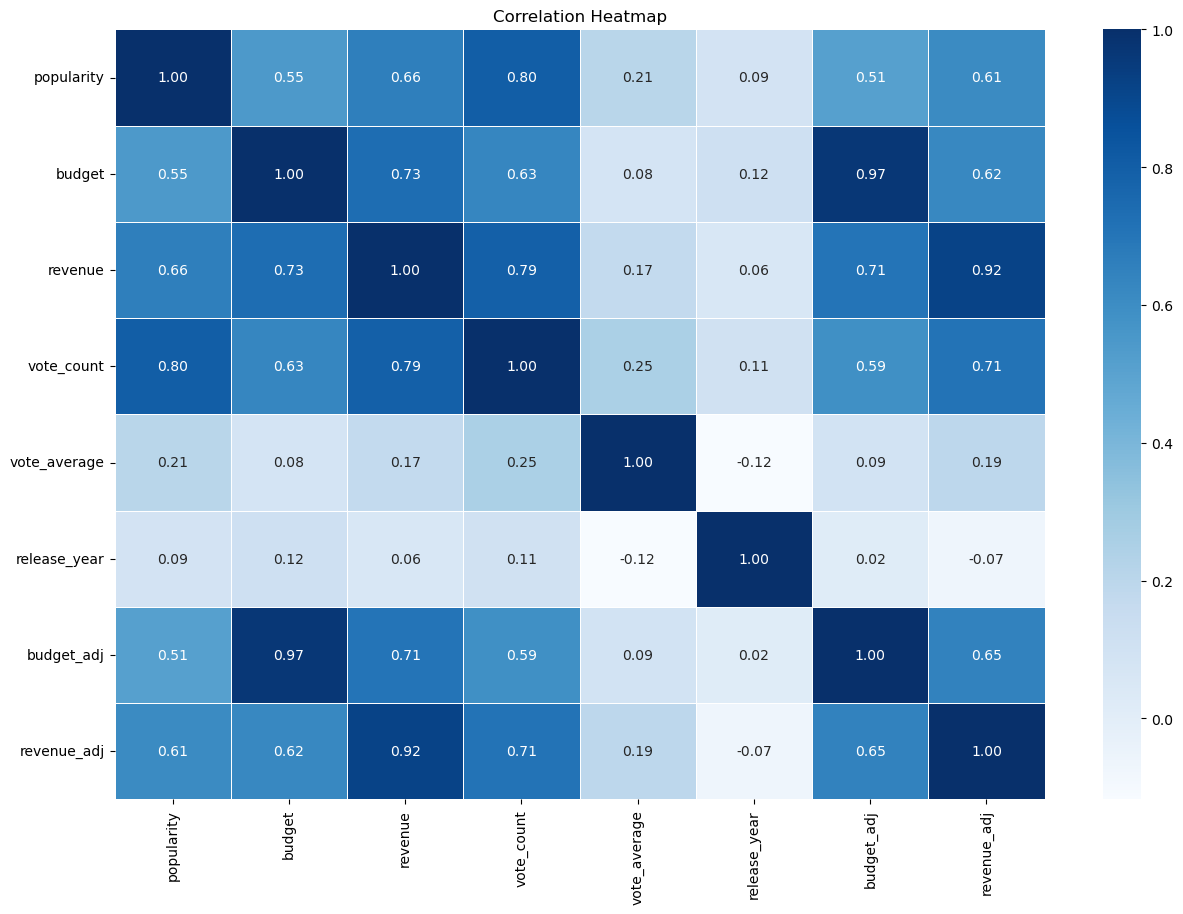

In [6]:
data_numeric = data.select_dtypes(include=['number'])
q0 = sns.heatmap(data_numeric.corr(), annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

show(q0 , title_label="Correlation Heatmap" , fig_size=(15 , 10))
# most of high budget movies tend to have more revenue

## Research Question 1  . what is the most common genres ? 
- **comedy** and **drama** are the most common genres  


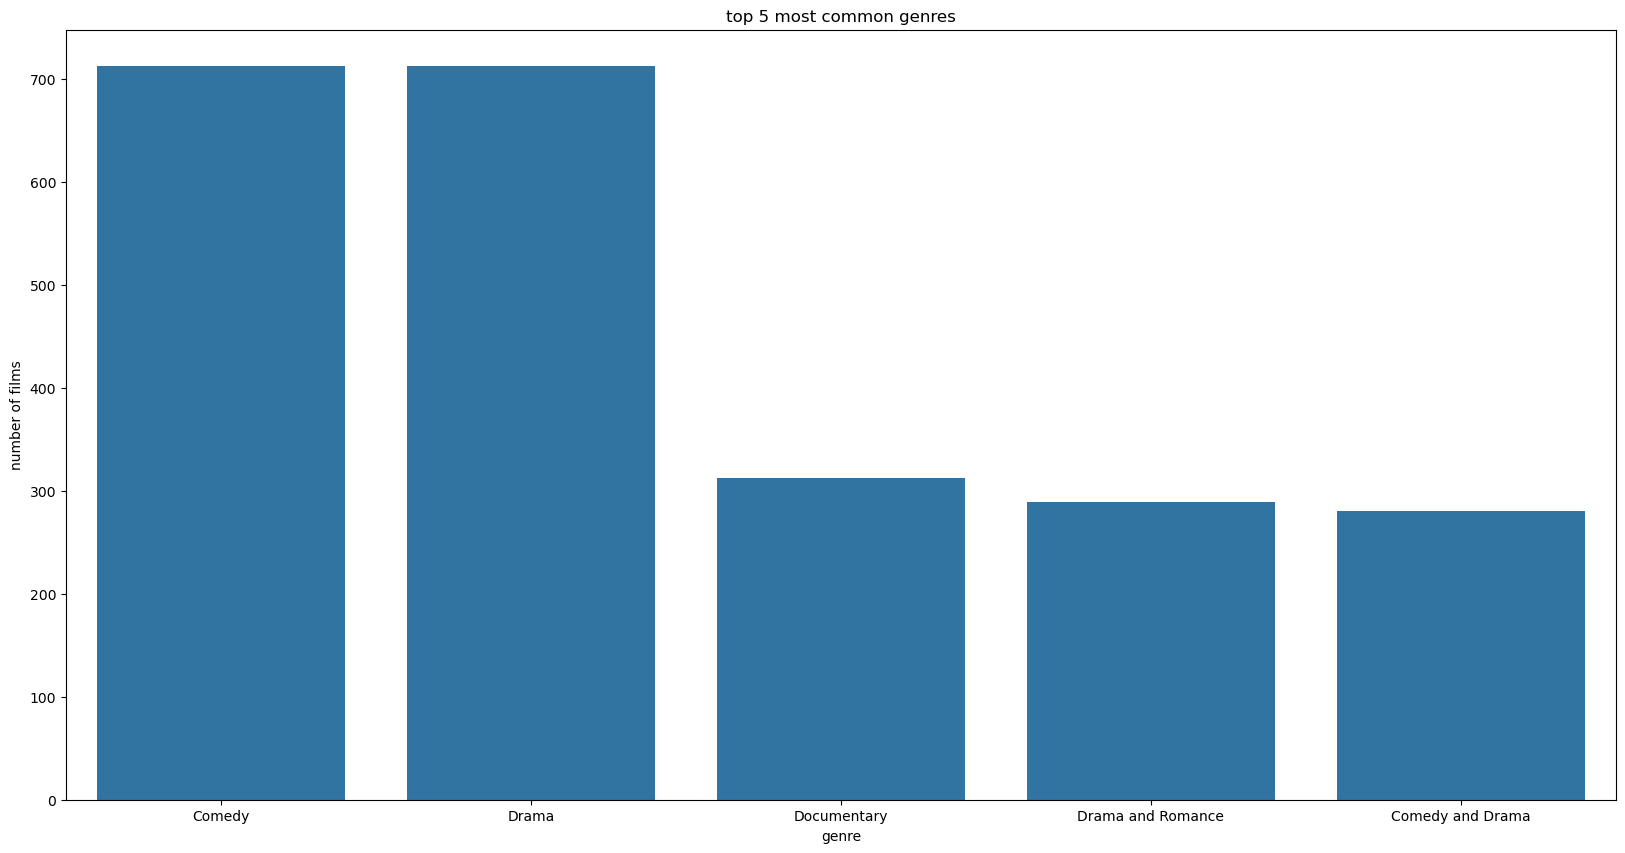

In [ ]:

top_5_genres = data['genres'].value_counts().nlargest(5) # here get the most 5 common genres  
top_5_genres.index = top_5_genres.index.str.replace("|", " and ") # here we replace | with and
top_5_df = top_5_genres.reset_index() # sns only work on data frame so i had to convert it to dataframe (vector)
top_5_df.columns = ['Genre', 'Count'] # here i created a columns called count and genere
q1 = sns.barplot(data=top_5_df, x="Genre", y="Count") # create a bar plot to show the count of films for each genre in the top 5 dataset 
show(q1 , title_label="top 5 most common genres" , x_label="genre" , y_label="number of films")

### Research Question 2  . what are the genres of the top five highest earning films ?
- the genres
    1. Action and Adventure and Fantasy and Science Fiction
    2. Drama and Romance and Thriller 
    3. Action and Adventure and Science Fiction and Thriller
    4. Science Fiction and Action and Adventure

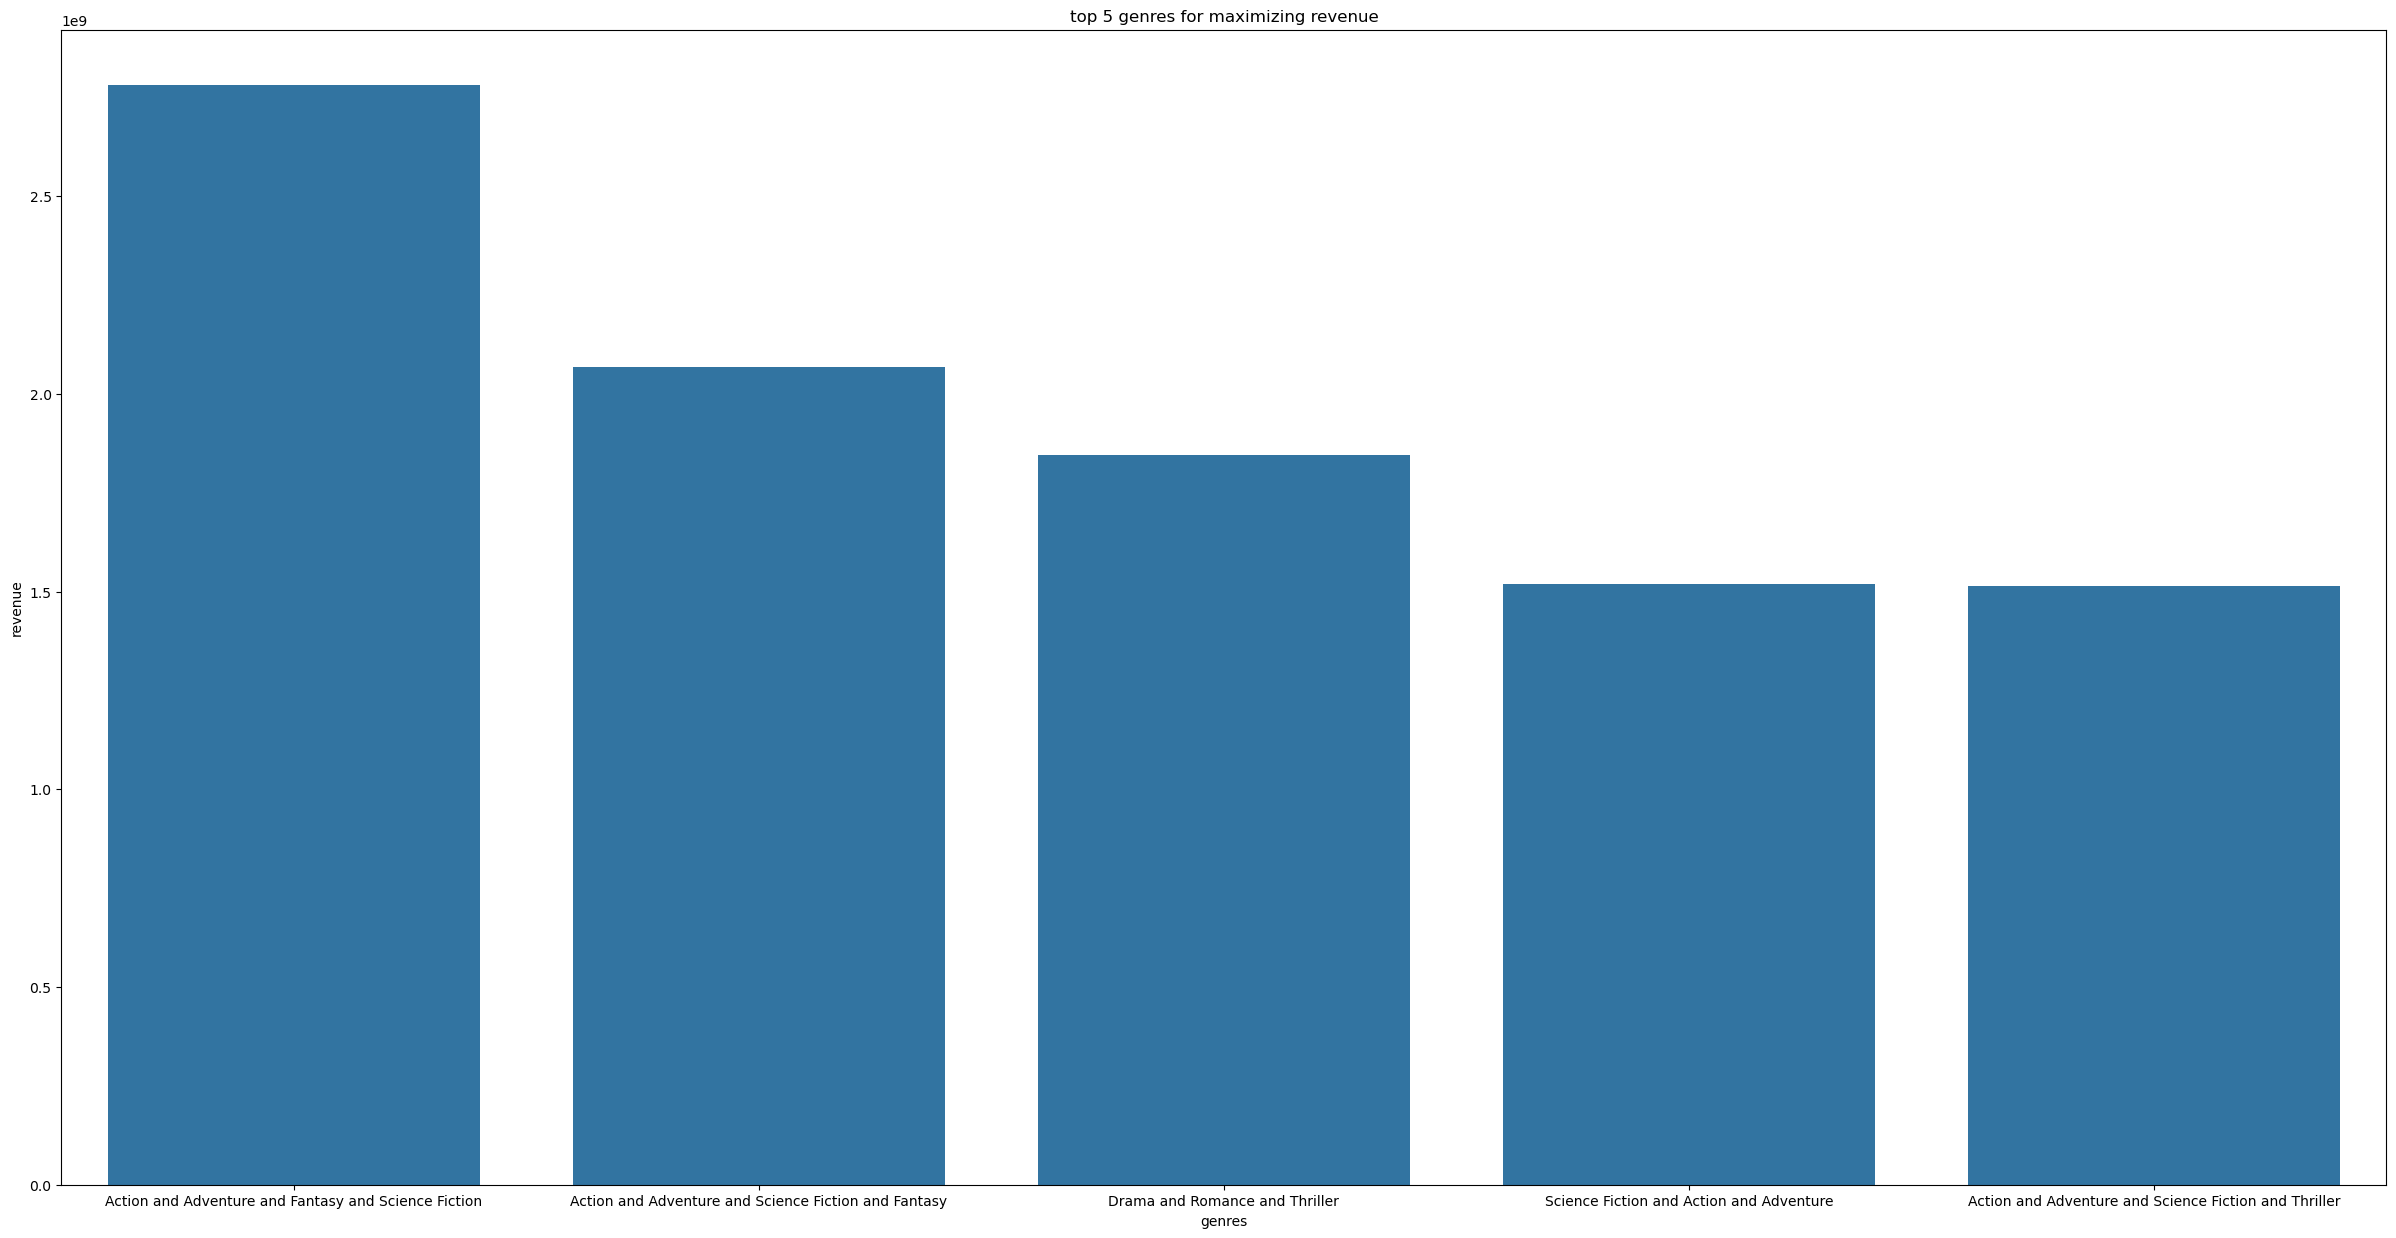

In [ ]:
top_5 = data.nlargest(5, 'revenue') # here to get the most common genres based on the revenue
top_5["genres"] = top_5["genres"].astype(str).str.replace("|", " and ") # here is to replace the the pipline with "and" to make it more readable
q2 = sns.barplot(data=top_5 , x="genres" , y="revenue") # create a bar plot to show revenue for each genre in the top 5 films
show(q2 , title_label="top 5 genres for maximizing revenue" , fig_size=(30 , 15)) # that is my function that shows the plot with a spacfic args 

### Research Question 3  . what are the top five highest earning films ?
- i found that the **top 5 highest grossing films** that generated the most revenue are  

  1. **avatar**  
  2. **avengers endgame**  
  3. **titanic**  
  4. **star wars the force awakens**  
  5. **avengers infinity war**  

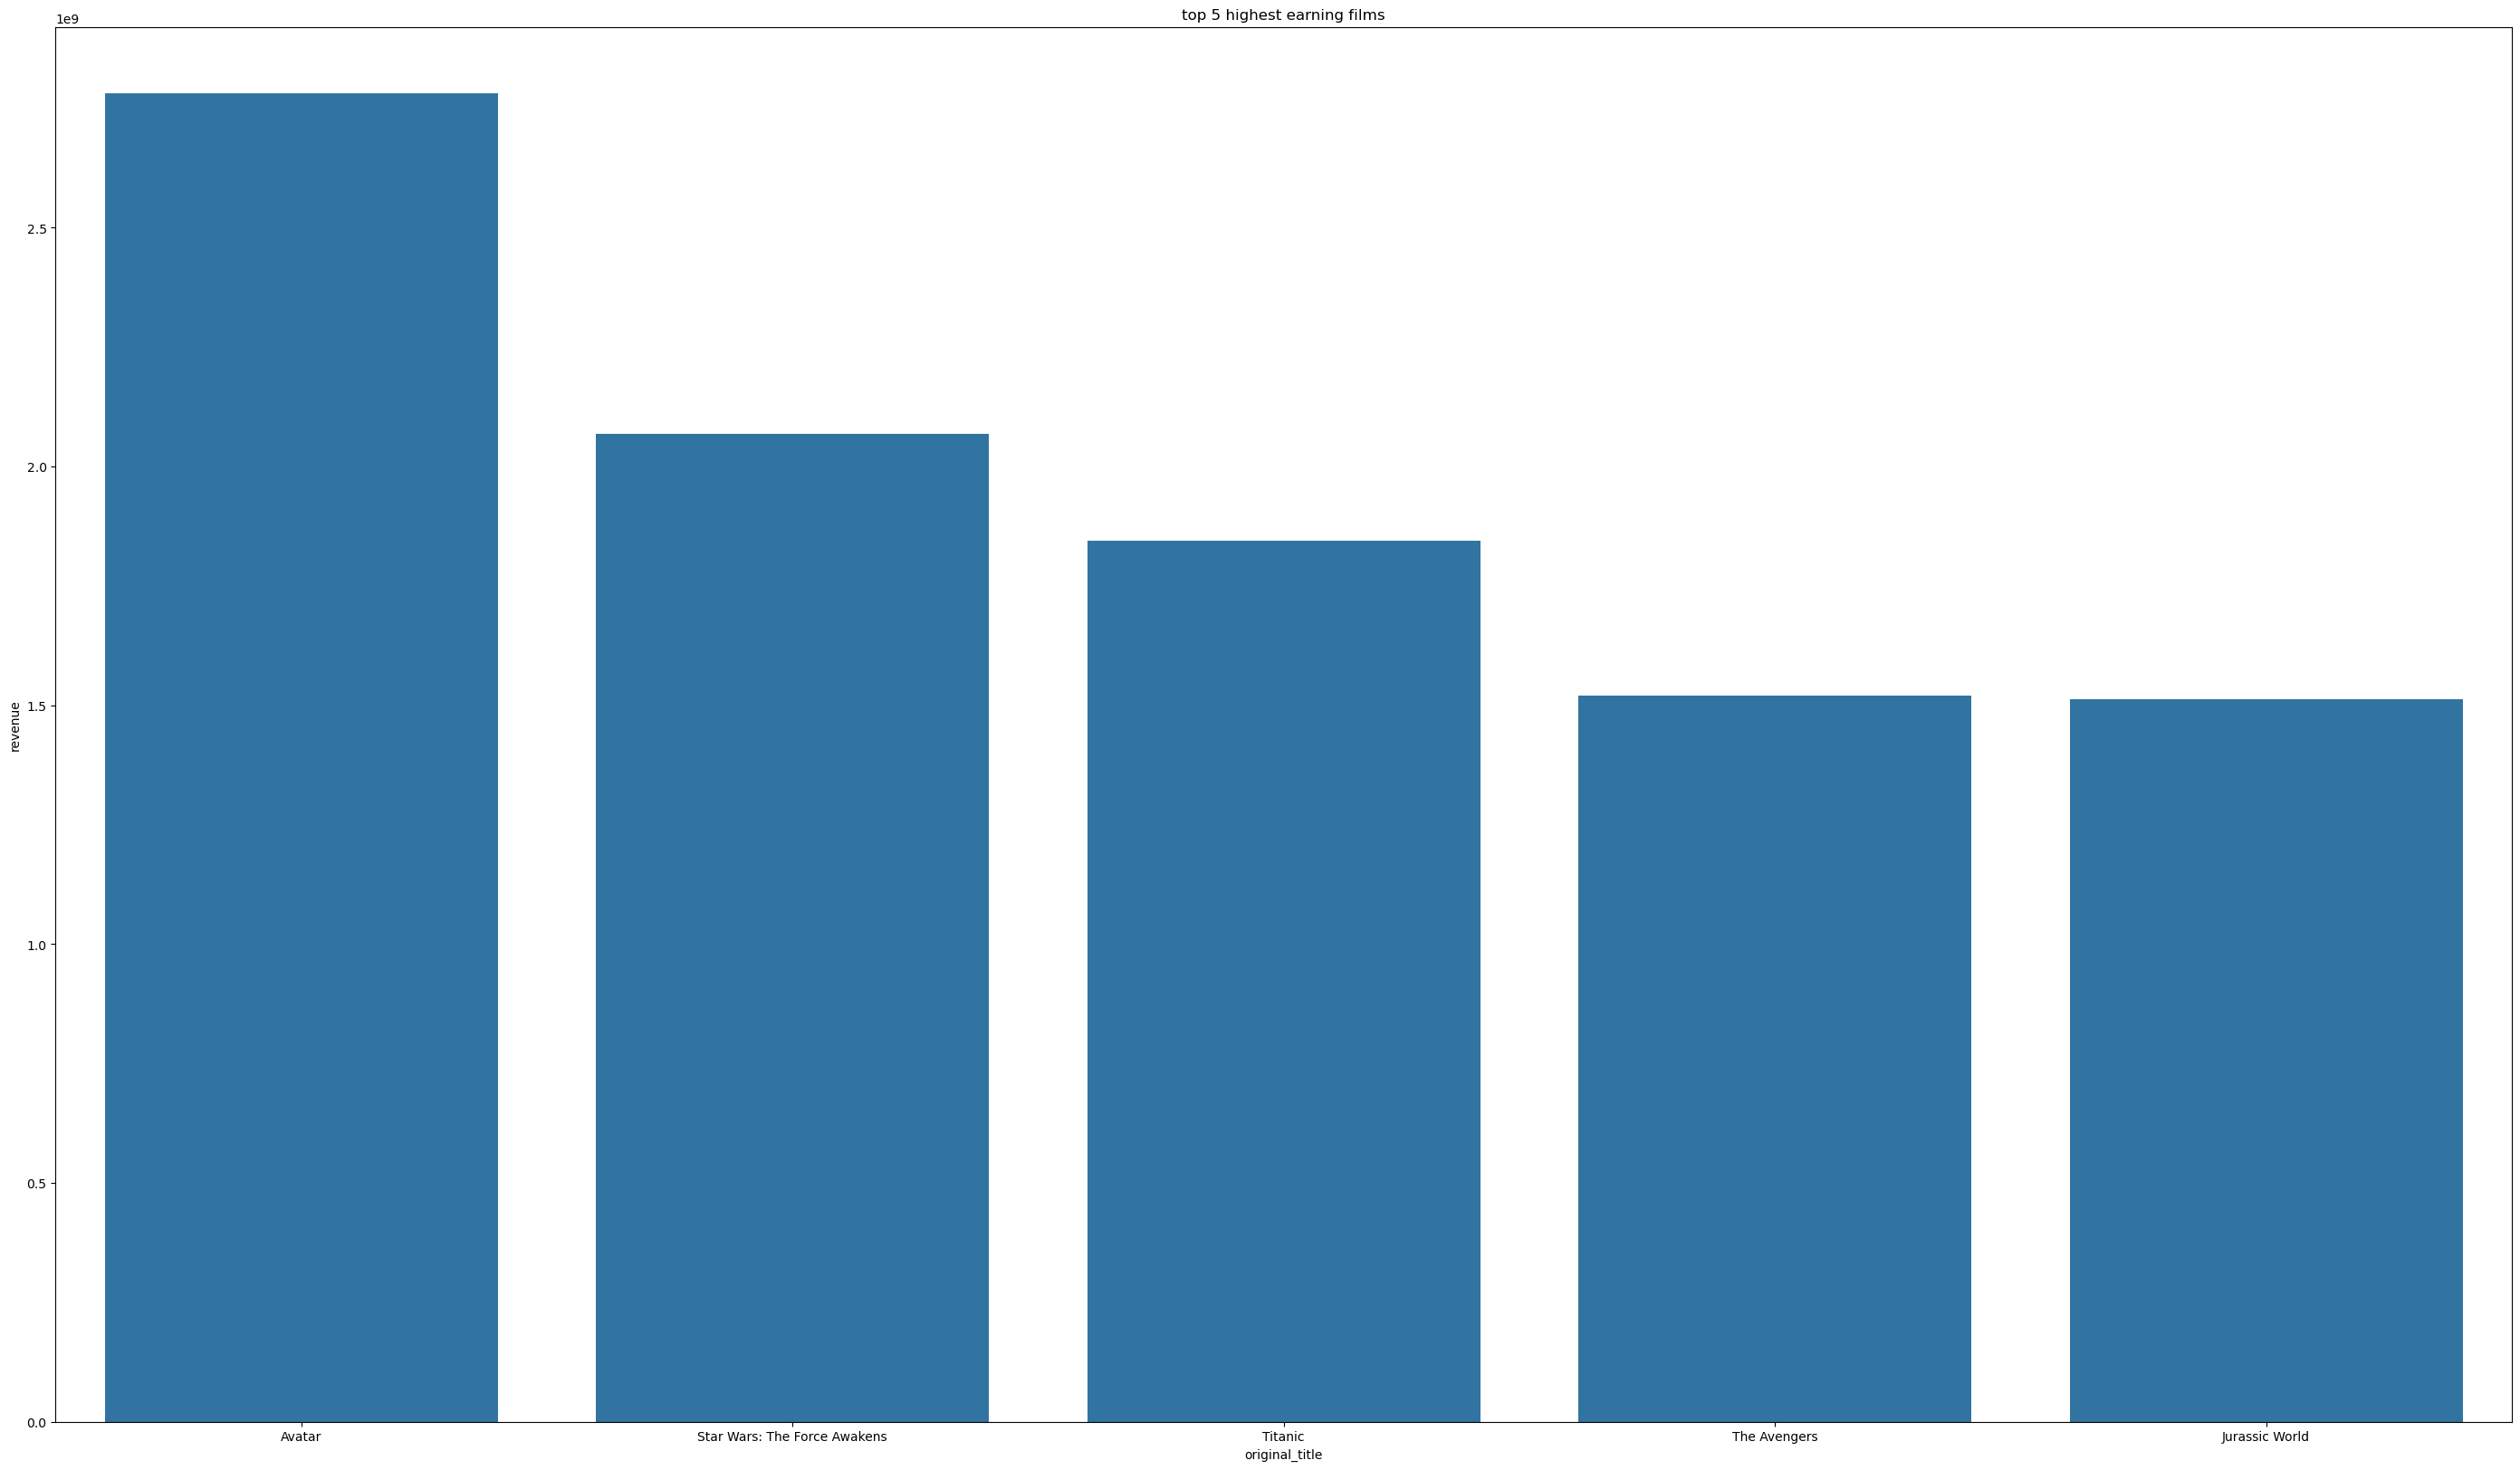

In [9]:
top_10 = data.nlargest(10, 'revenue') # here to get the larget 10 films based on the revenue
q3 = sns.barplot(data=top_5 , x="original_title" , y="revenue") # i created a bar plot based on top 10 films to graph them with the most revenue
show(q3 , title_label="top 5 highest earning films" , fig_size=(35 , 20)) # that is my function that shows the plot with a spacfic args

## Research Question 4  . Is that a relation between year and number of films ? 
### here i made histogram to count the number of films of each year
### and i found as the **years progress** the number of films tends to **increase** the distribution is **likely left skewed** and i observed a **pattern** where the number of films increases approximately **every two years**  

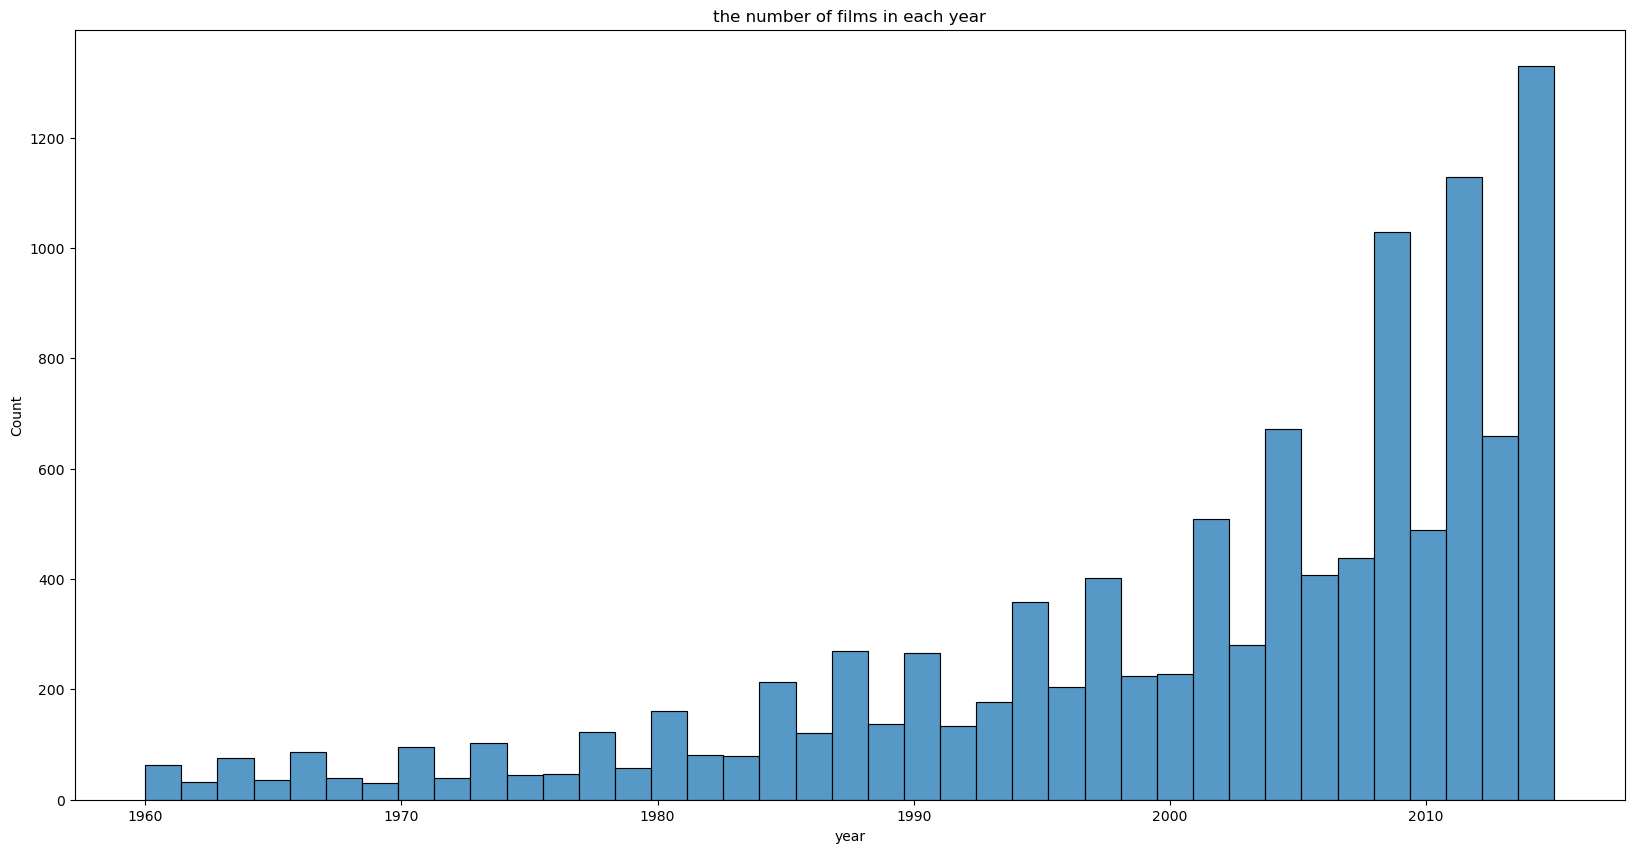

In [10]:
q4 = sns.histplot(data=data , x="release_year") # that variable is to make a histogram to count the number of films that have a spacfic year
show(q4 , x_label="year" , title_label="the number of films in each year") # that is my function that shows the plot with a spacfic args

<a id='conclusions'></a>

## conclusions  

- i found a **positive correlation** between **budget** and **revenue**  
- movies with **higher budgets** tend to generate **more revenue**  
- **comedy** and **drama** are the most common genres  
- the **top 5 highest grossing films** that generated the most revenue are  
- 

  1. **avatar**  
  2. **avengers endgame**  
  3. **titanic**  
  4. **star wars the force awakens**  
  5. **avengers infinity war**  

- as the **years progress** the number of films tends to **increase** the distribution is **likely left skewed** and i observed a **pattern** where the number of films increases approximately **every two years**  
- **limitation** the dataset is **not large enough** to ensure that my analysis is **fully accurate**  
- **suggestion** providing **more data samples** in the future would improve the analysis  

### final conclusion  
the analysis suggests that movies with higher budgets tend to generate more revenue and the number of films produced has been increasing over time however due to the dataset's limitations further research with a larger sample size is needed for more precise insights expanding the dataset could help refine these findings and uncover deeper trends in the film industry
